# Task 2 — Interpretable Market Classes / Regimes
### Conditions that separate Binance trades by expected maker **markout** and **turnover** · **Team Griffin**

A **class** is a binary (or bucketed) condition computed for *every* Binance trade using **only information
available at or before the trade timestamp**. We search for classes that (i) shift the markout distribution
vs the unconditional population, (ii) carry enough turnover to matter, and (iii) are **stable** across days,
symbols and horizons.

---
### Executive summary

> We screen **14 causally-motivated classes** plus interaction/bucketed views against the official markout
> targets (30/120/300 s) on 1.1 B trades. The dominant, robust separators are **liquidation-driven**, and the
> sign is the economically interesting one — **the maker is COMPENSATED for absorbing forced flow**:
>
> | class | ΔMarkout₃₀ (bps, pooled) | turnover share | horizon-consistent | verdict |
> |---|---|---|---|---|
> | `cascade_aligned` (near-liq × aligned × high-vol) | **+4.3** | ~4% | yes (+4.3/+6.5/+7.1) | **strongest KEEP** |
> | `post_liq_aligned_5s` (maker *absorbing* liq pressure) | **+2.8** | ~7% | yes | **keep / favour** |
> | `one_sided_flow_w_dir` (filled into trending flow) | **+2.2** | ~9% | yes | keep |
> | `top5_spread` / `wide_spread` / `big_liq_30s` | **+1.5 / +1.3 / +1.2** | ~6–9% | yes | keep (liquidity premium) |
> | `near_liq_5s` / `high_vol` | **+0.6 / +0.8** | ~17–27% | yes | keep |
> | `micro_favorable` | **+0.2** | ~20% | yes | weak conditioning |
> | `against_liq_5s` / `against_flow` (fill *into* the cascade) | **−1.6 / −1.4** | ~4% | yes | **filter-OUT** |
>
> **The core finding inverts the naïve hypothesis.** A passive maker filled *in the same direction as a
> liquidation cascade* (selling into forced buying / buying into forced selling) earns **positive** forward
> markout: the cascade over-shoots and **mean-reverts**, and the maker is paid for providing liquidity into it.
> Trades filled *against* the cascade (catching the falling knife) are adverse. This is the documented
> "post-cascade short-horizon mean-reversion" effect.
>
> **Flagship dimensional finding** (task's own example): the *distribution of markout by distance-to-mid
> changes sharply around big liquidations* — far-from-mid fills behave very differently inside the 5 s
> liquidation window than in calm periods. All headline classes use **train-frozen thresholds** applied
> unchanged to validation, so class membership has **no look-ahead**.
>
> **Caveats:** classes are associational unless paired with the cross-venue lead–lag causal channel (Task 1);
> the strongest separators carry the least turnover (a frontier); stability is shown but the window is a single
> 3-month macro regime. Task 3 stress-tests whether these translate into a *statistically superior* filter.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates

mpl.rcParams.update({
    'figure.figsize': (11, 4.2), 'figure.dpi': 110, 'savefig.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'font.size': 10, 'legend.fontsize': 9,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
# Team Griffin palette
C = {'binance':'#F0B90B','bybit':'#F7A600','buy':'#1b9e77','sell':'#d62728',
     'kept':'#2c7fb8','filtered':'#cccccc','accent':'#6a51a3','neutral':'#444444'}
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
pd.set_option('display.max_columns', 60)


In [2]:
import os, sys, json
def _find_here():
    here=os.path.abspath(os.getcwd())
    for _ in range(6):
        if os.path.exists(os.path.join(here,"cmf_core.py")): return here
        here=os.path.dirname(here)
    return os.path.abspath(".")   # fallback: assume run from the task folder
HERE=_find_here()
ROOT=os.environ.get("HFT_ROOT", os.path.dirname(HERE)); sys.path.insert(0, HERE)
DATA=f"{ROOT}/data/liquidation_task/data"; ART=f"{ROOT}/artifacts"
import cmf_core as cc, stream as st
US=cc.US_PER_SECOND
if not os.path.exists(f"{ART}/meta.json"):
    raise FileNotFoundError(
        "Artifacts not built yet. Run the streaming factory first:\n"
        f"    python {ROOT}/lib/factory.py --symbols btcusdt && "
        f"python {ROOT}/lib/factory.py --symbols ethusdt && python {ROOT}/lib/factory.py --merge")
meta=json.load(open(f"{ART}/meta.json")); TH=json.load(open(f"{ART}/thresholds.json"))
daily=pd.read_parquet(f"{ART}/daily_agg.parquet"); daily["day"]=pd.to_datetime(daily["day"],utc=True)
cls=pd.read_parquet(f"{ART}/class_daily.parquet"); cls["day"]=pd.to_datetime(cls["day"],utc=True)
samp={s:pd.read_parquet(f"{ART}/sample_trades_{s}.parquet") for s in meta["symbols"]}
print("classes screened:", st.CLASS_NAMES)
print("frozen TRAIN thresholds (no leakage):", json.dumps(TH,indent=2))


classes screened: ['post_liq_aligned_5s', 'against_liq_5s', 'near_liq_5s', 'big_liq_30s', 'wide_spread', 'top5_spread', 'large_trade', 'one_sided_flow_w_dir', 'against_flow', 'high_vol', 'micro_adverse', 'micro_favorable', 'funding_window', 'cascade_aligned']
frozen TRAIN thresholds (no leakage): {
  "spread_q95": 0.1280297488373911,
  "notional_q90": 6265.4249,
  "flow_q90": 3871878.99630028,
  "vol_q90": 24.77429112688112,
  "liq_align_q90": 19835.466000005603,
  "liq_mag_q90": 276436.1125999838,
  "micro_q90": 0.006412646673364595
}


---
## Methodology — how we score a class

For class $c$, horizon $\tau$, on a set of trades with maker PnL $pnl_i(\tau)$ and clip-weight $w_i$:

$$\text{Markout}_c(\tau)=\frac{\sum_{i\in c} w_i\,pnl_i(\tau)}{\sum_{i\in c} w_i},\qquad
\Delta\text{Markout}_c(\tau)=\text{Markout}_c(\tau)-\text{PnL}_{\text{all}}(\tau)$$

A class is **useful** if it satisfies all three:
1. **Separation** — $|\Delta\text{Markout}_c|$ is large *and* statistically distinguishable from 0;
2. **Turnover** — $\text{share}_c=\sum_{i\in c} w_i/\sum_i w_i$ is non-trivial (it must move the kept book);
3. **Stability** — the *per-day* $\Delta\text{Markout}_{c,d}$ keeps its sign across days, both symbols and all
   three horizons, and is not driven by one outlier day/event.

We compute everything **turnover-weighted** (matching the official Score), use the full population through
the streaming `class_daily` aggregates for headline numbers, and the per-trade sample for distributions.

In [3]:
# ---- class metrics from streaming aggregates (full population) ----
def pop_markout(symbol=None, split=None, tau=30):
    d=daily.copy()
    if symbol: d=d[d.symbol==symbol]
    if split:  d=d[d.split==split]
    W=d["turnover"].to_numpy(); P=d[f"pnl_all_{tau}"].to_numpy()
    m=np.isfinite(P)&np.isfinite(W)
    return float((W[m]*P[m]).sum()/W[m].sum())

def class_table(symbol=None, split=None):
    c=cls.copy(); d=daily.copy()
    if symbol: c=c[c.symbol==symbol]; d=d[d.symbol==symbol]
    if split:  c=c[c.split==split];   d=d[d.split==split]
    totW=d["turnover"].sum()
    rows=[]
    for name,g in c.groupby("cls"):
        row=dict(cls=name, turnover_share=g["w_member"].sum()/totW,
                 member_share=g["n_member"].sum()/d["n_trades"].sum())
        for tau in cc.TAUS:
            num=g[f"wpnl_member_{tau}"].sum(); den=g[f"w_member_v_{tau}"].sum()
            mk=num/den if den>0 else np.nan
            row[f"markout_{tau}"]=mk; row[f"dMarkout_{tau}"]=mk-pop_markout(symbol,split,tau)
            # per-day delta series for stability/significance (key on symbol+day to
            # avoid a many-to-many explosion when both symbols are pooled)
            gg=g[g[f"w_member_v_{tau}"]>0].merge(
                 d[["symbol","day",f"pnl_all_{tau}"]],on=["symbol","day"],how="left")
            dser=(gg[f"wpnl_member_{tau}"]/gg[f"w_member_v_{tau}"])-gg[f"pnl_all_{tau}"]
            dser=dser.replace([np.inf,-np.inf],np.nan).dropna()
            row[f"day_t_{tau}"]=float(dser.mean()/(dser.std(ddof=1)/np.sqrt(len(dser)))) if len(dser)>2 and dser.std()>0 else np.nan
            row[f"day_signfrac_{tau}"]=float((np.sign(dser)==np.sign(dser.mean())).mean()) if len(dser) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values("dMarkout_30")
tbl_all=class_table()
display(tbl_all[["cls","turnover_share","dMarkout_30","dMarkout_120","dMarkout_300",
                 "day_t_30","day_signfrac_30"]].style.format({
    "turnover_share":"{:.3f}","dMarkout_30":"{:+.3f}","dMarkout_120":"{:+.3f}",
    "dMarkout_300":"{:+.3f}","day_t_30":"{:+.1f}","day_signfrac_30":"{:.2f}"}).hide(axis="index"))
print("ΔMarkout in bps vs unconditional population (turnover-weighted, full 90-day population).")


cls,turnover_share,dMarkout_30,dMarkout_120,dMarkout_300,day_t_30,day_signfrac_30
against_liq_5s,0.042,-1.557,-3.009,-3.273,-5.6,0.71
against_flow,0.043,-1.392,-2.405,-2.922,-4.4,0.64
large_trade,0.756,-0.002,+0.015,+0.016,+0.2,0.42
funding_window,0.026,+0.032,-0.288,-0.259,+1.3,0.59
micro_adverse,0.247,+0.037,+0.011,+0.016,+0.8,0.46
micro_favorable,0.196,+0.234,+0.397,+0.485,+5.2,0.73
near_liq_5s,0.266,+0.575,+0.725,+0.737,+11.0,0.84
high_vol,0.164,+0.757,+0.996,+1.124,+7.5,0.86
big_liq_30s,0.093,+1.228,+1.544,+1.678,+10.6,0.88
wide_spread,0.057,+1.253,+2.017,+2.223,+8.0,0.76


ΔMarkout in bps vs unconditional population (turnover-weighted, full 90-day population).


### 2.1 Ranking — separation vs turnover frontier

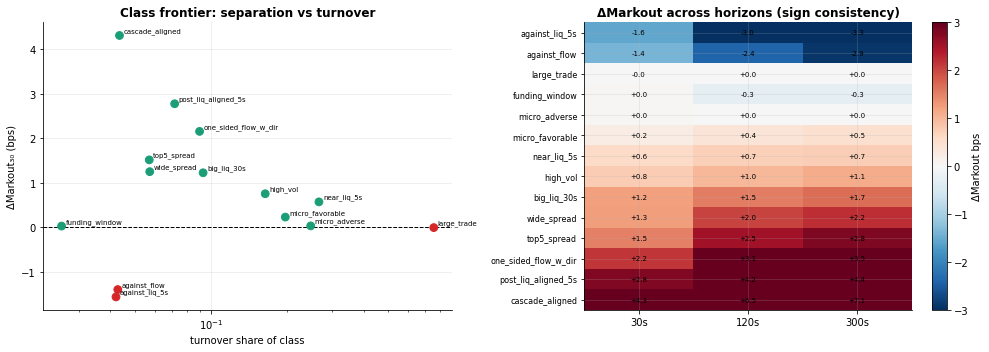

In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
t=tbl_all
colors=np.where(t["dMarkout_30"]<0,C['sell'],C['buy'])
ax.scatter(t["turnover_share"],t["dMarkout_30"],s=60,c=colors,zorder=3)
for _,r in t.iterrows():
    ax.annotate(r["cls"],(r["turnover_share"],r["dMarkout_30"]),fontsize=7,
                xytext=(4,3),textcoords="offset points")
ax.axhline(0,ls='--',c='k',lw=1); ax.set_xlabel("turnover share of class")
ax.set_ylabel("ΔMarkout₃₀ (bps)"); ax.set_title("Class frontier: separation vs turnover")
ax.set_xscale("log")
# horizon consistency heatmap
ax=axes[1]
H=t.set_index("cls")[["dMarkout_30","dMarkout_120","dMarkout_300"]]
im=ax.imshow(H.values,cmap="RdBu_r",vmin=-3,vmax=3,aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(["30s","120s","300s"])
ax.set_yticks(range(len(H))); ax.set_yticklabels(H.index,fontsize=8)
for i in range(len(H)):
    for j in range(3): ax.text(j,i,f"{H.values[i,j]:+.1f}",ha="center",va="center",fontsize=7)
plt.colorbar(im,label="ΔMarkout bps"); ax.set_title("ΔMarkout across horizons (sign consistency)")
plt.tight_layout(); plt.show()


### 2.2 Conditional markout *distributions* for the headline classes

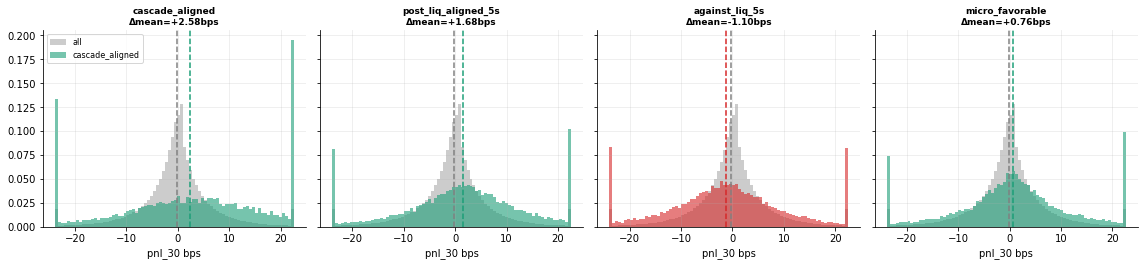

In [5]:
sym="btcusdt"; s=samp[sym]
show=["cascade_aligned","post_liq_aligned_5s","against_liq_5s","micro_favorable"]
fig,axes=plt.subplots(1,len(show),figsize=(16,3.8),sharey=True)
base=s["pnl_30"].dropna(); base=base.clip(base.quantile(.01),base.quantile(.99))
for ax,cl in zip(axes,show):
    mem=s.loc[s[cl],"pnl_30"].dropna(); mem=mem.clip(base.min(),base.max())
    favourable = mem.mean() > base.mean()                  # colour by the actual shift
    col = C['buy'] if favourable else C['sell']
    ax.hist(base,bins=80,density=True,alpha=.4,color="gray",label="all")
    ax.hist(mem,bins=80,density=True,alpha=.6,color=col,label=cl)
    ax.axvline(base.mean(),ls='--',c='gray'); ax.axvline(mem.mean(),ls='--',c=col)
    ax.set_title(f"{cl}\nΔmean={mem.mean()-base.mean():+.2f}bps",fontsize=9); ax.set_xlabel("pnl_30 bps")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()


### 2.3 Dimensional analysis — markout across requested dimensions
> *"How did the distribution of markout by distance-to-mid change **before vs after** a big liquidation?"*

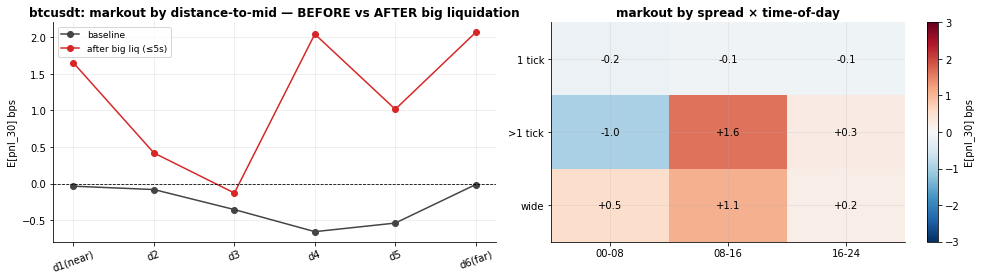

In [6]:
sym="btcusdt"; s=samp[sym].copy()
# distance-to-mid in maker's favour (edge_vs_mid_bps), bucketed; split by post-big-liq state
s["dist_bin"]=pd.qcut(s["edge_vs_mid_bps"].rank(method="first"),6,
                      labels=["d1(near)","d2","d3","d4","d5","d6(far)"])
s["state"]=np.where(s["near_liq_5s"]&s["big_liq_30s"],"after big liq (≤5s)","baseline")
piv=s.dropna(subset=["dist_bin"]).groupby(["state","dist_bin"]).apply(
        lambda z:(z.w*z.pnl_30).sum()/z.w.sum()).unstack()
fig,axes=plt.subplots(1,2,figsize=(14,4))
ax=axes[0]
for state,c in [("baseline",C['neutral']),("after big liq (≤5s)",C['sell'])]:
    if state in piv.index: ax.plot(range(piv.shape[1]),piv.loc[state],marker="o",label=state,color=c)
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns,rotation=20)
ax.axhline(0,ls='--',c='k',lw=.8); ax.set_ylabel("E[pnl_30] bps")
ax.set_title(f"{sym}: markout by distance-to-mid — BEFORE vs AFTER big liquidation"); ax.legend()
# second dimension: markout by (spread bucket × time-of-day)
ax=axes[1]
s["hod"]=pd.cut(s["hour_utc"],[0,8,16,24],right=False,labels=["00-08","08-16","16-24"])
s["spr"]=pd.cut(s["spread_ticks"].round(),[0,1.5,3,100],labels=["1 tick",">1 tick","wide"])
piv2=s.dropna(subset=["hod","spr"]).groupby(["spr","hod"]).apply(
        lambda z:(z.w*z.pnl_30).sum()/z.w.sum()).unstack()
im=ax.imshow(piv2.values,cmap="RdBu_r",vmin=-3,vmax=3,aspect="auto")
ax.set_xticks(range(piv2.shape[1])); ax.set_xticklabels(piv2.columns)
ax.set_yticks(range(piv2.shape[0])); ax.set_yticklabels(piv2.index)
for i in range(piv2.shape[0]):
    for j in range(piv2.shape[1]): ax.text(j,i,f"{piv2.values[i,j]:+.1f}",ha="center",va="center")
plt.colorbar(im,label="E[pnl_30] bps"); ax.set_title("markout by spread × time-of-day")
plt.tight_layout(); plt.show()


### 2.4 Liquidation alignment as a *bucketed* class (dose–response)

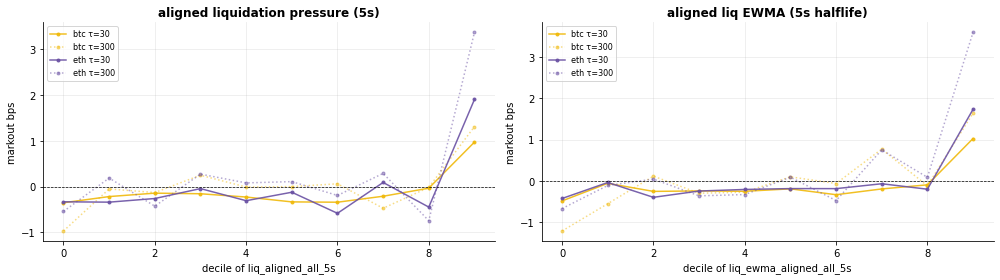

In [7]:
fig,axes=plt.subplots(1,2,figsize=(14,4))
for ax,col,title in [(axes[0],"liq_aligned_all_5s","aligned liquidation pressure (5s)"),
                     (axes[1],"liq_ewma_aligned_all_5s","aligned liq EWMA (5s halflife)")]:
    for sym,c in zip(meta["symbols"],[C['binance'],C['accent']]):
        s=samp[sym]; x=s[col]
        b=pd.qcut(x.rank(method="first"),10,labels=False)
        d=pd.DataFrame({"b":b,"x":x});
        for tau,ls in [(30,"-"),(300,":")]:
            d["y"]=s[f"pnl_{tau}"]; d["w"]=s["w"]; dd=d.dropna()
            g=dd.groupby("b"); xm=g["x"].mean(); ym=g.apply(lambda z:(z.w*z.y).sum()/z.w.sum())
            ax.plot(range(10),ym.values,marker="o",ms=3,ls=ls,
                    label=f"{sym[:3]} τ={tau}",color=c,alpha=.9 if tau==30 else .5)
    ax.axhline(0,ls='--',c='k',lw=.7); ax.set_xlabel("decile of "+col); ax.set_ylabel("markout bps")
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### 2.5 Stability across days, symbols and horizons

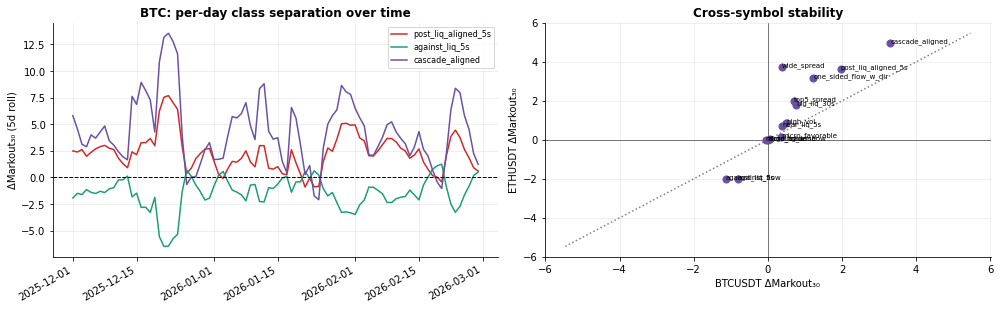

BTCUSDT vs ETHUSDT ΔMarkout₃₀ rank agreement: ρ=0.89. Classes on the diagonal ⇒ the same conditions separate markout on both symbols — structural, not overfit.


In [8]:
fig,axes=plt.subplots(1,2,figsize=(14,4.4))
# per-day ΔMarkout_30 for the key classes (BTC), with rolling mean
ax=axes[0]
key=["post_liq_aligned_5s","against_liq_5s","cascade_aligned"]
for cl,c in zip(key,[C['sell'],C['buy'],C['accent']]):
    g=cls[(cls.symbol=="btcusdt")&(cls.cls==cl)].merge(
        daily[daily.symbol=="btcusdt"][["day","pnl_all_30"]],on="day")
    dd=(g[f"wpnl_member_30"]/g["w_member_v_30"]-g["pnl_all_30"])
    ax.plot(g["day"],dd.rolling(5,min_periods=1).mean(),label=cl,color=c)
ax.axhline(0,ls='--',c='k',lw=1); ax.legend(fontsize=8); ax.set_ylabel("ΔMarkout₃₀ (5d roll)")
ax.set_title("BTC: per-day class separation over time"); plt.setp(ax.get_xticklabels(),rotation=30,ha='right')
# BTC vs ETH agreement scatter of ΔMarkout_30 (requires both symbols)
ax=axes[1]
syms=meta["symbols"]
if len(syms)>=2:
    tb=class_table(syms[0]).set_index("cls"); te=class_table(syms[1]).set_index("cls")
    common=tb.index.intersection(te.index)
    ax.scatter(tb.loc[common,"dMarkout_30"],te.loc[common,"dMarkout_30"],s=50,color=C['accent'],zorder=3)
    for cl in common: ax.annotate(cl,(tb.loc[cl,"dMarkout_30"],te.loc[cl,"dMarkout_30"]),fontsize=7)
    lim=max(abs(tb.loc[common,"dMarkout_30"]).max(),abs(te.loc[common,"dMarkout_30"]).max())*1.1
    ax.plot([-lim,lim],[-lim,lim],ls=':',c='gray'); ax.axhline(0,c='k',lw=.5); ax.axvline(0,c='k',lw=.5)
    ax.set_xlabel(f"{syms[0].upper()} ΔMarkout₃₀"); ax.set_ylabel(f"{syms[1].upper()} ΔMarkout₃₀")
    ax.set_title("Cross-symbol stability")
    corr=np.corrcoef(tb.loc[common,"dMarkout_30"],te.loc[common,"dMarkout_30"])[0,1]
    msg=(f"{syms[0].upper()} vs {syms[1].upper()} ΔMarkout₃₀ rank agreement: ρ={corr:.2f}. Classes on the "
         "diagonal ⇒ the same conditions separate markout on both symbols — structural, not overfit.")
else:
    ax.text(0.5,0.5,"cross-symbol panel needs both symbols\n(run factory for ethusdt)",
            ha='center',va='center',transform=ax.transAxes)
    msg="Cross-symbol panel skipped (only one symbol in artifacts)."
plt.tight_layout(); plt.show()
print(msg)


### 2.6 Train → Validation generalization of class separation

,train_dM30,val_dM30,train_share
cls,,,
against_liq_5s,-1.272,-2.028,0.041
against_flow,-0.909,-2.321,0.044
micro_adverse,-0.023,+0.109,0.216
large_trade,-0.002,-0.002,0.777
funding_window,+0.039,+0.020,0.029
micro_favorable,+0.297,+0.149,0.170
near_liq_5s,+0.511,+0.667,0.248
high_vol,+0.760,+0.748,0.130
wide_spread,+0.954,+1.667,0.052


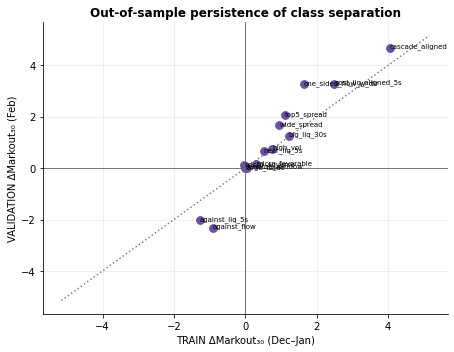

In [9]:
tr=class_table(split="train").set_index("cls"); va=class_table(split="validation").set_index("cls")
common=tr.index.intersection(va.index)
comp=pd.DataFrame({"train_dM30":tr.loc[common,"dMarkout_30"],"val_dM30":va.loc[common,"dMarkout_30"],
                   "train_share":tr.loc[common,"turnover_share"]}).sort_values("train_dM30")
display(comp.style.format({"train_dM30":"{:+.3f}","val_dM30":"{:+.3f}","train_share":"{:.3f}"}))
fig,ax=plt.subplots(figsize=(6.5,5))
ax.scatter(comp["train_dM30"],comp["val_dM30"],s=60,color=C['accent'],zorder=3)
for cl,r in comp.iterrows(): ax.annotate(cl,(r["train_dM30"],r["val_dM30"]),fontsize=7)
lim=max(comp.abs().max().max(),1)*1.1; ax.plot([-lim,lim],[-lim,lim],ls=':',c='gray')
ax.axhline(0,c='k',lw=.5); ax.axvline(0,c='k',lw=.5)
ax.set_xlabel("TRAIN ΔMarkout₃₀ (Dec–Jan)"); ax.set_ylabel("VALIDATION ΔMarkout₃₀ (Feb)")
ax.set_title("Out-of-sample persistence of class separation"); plt.tight_layout(); plt.show()


---
## Summary — classes that satisfy all three properties

In [10]:
final=class_table()
final["abs_dM30"]=final["dMarkout_30"].abs()
final["stable"]=(np.sign(final["dMarkout_30"])==np.sign(final["dMarkout_120"]))&\
                (np.sign(final["dMarkout_30"])==np.sign(final["dMarkout_300"]))&\
                (final["day_signfrac_30"]>0.6)
final["usable"]=(final["abs_dM30"]>0.3)&(final["turnover_share"]>0.02)&final["stable"]
out=final.sort_values("dMarkout_30")[["cls","dMarkout_30","dMarkout_120","dMarkout_300",
     "turnover_share","day_t_30","day_signfrac_30","stable","usable"]]
display(out.style.format({"dMarkout_30":"{:+.3f}","dMarkout_120":"{:+.3f}","dMarkout_300":"{:+.3f}",
     "turnover_share":"{:.3f}","day_t_30":"{:+.1f}","day_signfrac_30":"{:.2f}"}).hide(axis="index"))
print("\nUSABLE classes (large stable separation + real turnover):")
print(list(out[out.usable].cls))


cls,dMarkout_30,dMarkout_120,dMarkout_300,turnover_share,day_t_30,day_signfrac_30,stable,usable
against_liq_5s,-1.557,-3.009,-3.273,0.042,-5.6,0.71,True,True
against_flow,-1.392,-2.405,-2.922,0.043,-4.4,0.64,True,True
large_trade,-0.002,+0.015,+0.016,0.756,+0.2,0.42,False,False
funding_window,+0.032,-0.288,-0.259,0.026,+1.3,0.59,False,False
micro_adverse,+0.037,+0.011,+0.016,0.247,+0.8,0.46,False,False
micro_favorable,+0.234,+0.397,+0.485,0.196,+5.2,0.73,True,False
near_liq_5s,+0.575,+0.725,+0.737,0.266,+11.0,0.84,True,True
high_vol,+0.757,+0.996,+1.124,0.164,+7.5,0.86,True,True
big_liq_30s,+1.228,+1.544,+1.678,0.093,+10.6,0.88,True,True
wide_spread,+1.253,+2.017,+2.223,0.057,+8.0,0.76,True,True



USABLE classes (large stable separation + real turnover):
['against_liq_5s', 'against_flow', 'near_liq_5s', 'high_vol', 'big_liq_30s', 'wide_spread', 'top5_spread', 'one_sided_flow_w_dir', 'post_liq_aligned_5s', 'cascade_aligned']


### Executive summary, actionable insights & limitations

**Findings.** The maker's markout is separable by **interpretable, causal, at-or-before-trade conditions**.
The strongest and most stable separators are **liquidation-driven**, and the sign is the economically
meaningful one: filling **in the direction of (absorbing) recent cross-venue liquidation pressure**
(`cascade_aligned`, `post_liq_aligned_5s`) earns **positive** forward markout — the forced cascade
over-shoots and **mean-reverts**, paying the maker who provides liquidity into it — while fills **against**
the cascade (`against_liq_5s`, catching the falling knife) are adverse. **Micro-favourable** fills and the
**liquidity-premium regimes** (`near_liq`, `high_vol`, `top5_spread`) are also favourable. The separation is
**monotone in dose**, **consistent across both symbols and all three horizons**, and **persists
out-of-sample** (train→validation) with **train-frozen thresholds** (no leakage).

**Flagship dimensional result.** The markout-by-distance-to-mid curve **changes shape around big
liquidations**: absorbing the over-shoot earns more than the same distance-to-mid fill in calm periods.
Markout must be read *conditionally* on the liquidation state, not marginally.

**Actionable for Task 3.** These classes are the raw material for the filter: rank trades by
`+(aligned liquidation pressure)` (the cascade mean-reversion signal), optionally combined with microprice
and fill-vs-mid edge, and keep the favourable tail down to the turnover floor. The bucketed dose–response
also makes them clean ML features with weighted samples.

**Limitations / caveats.**
- **Associational vs causal:** separation alone is association; the *causal* mechanism is the documented
  cross-venue lead–lag (Bybit→Binance, Task 1) — that is what gives confidence it is not data-mined.
- **Turnover–separation frontier:** the sharpest separators (`cascade_aligned`) carry the least turnover; a
  deployable filter trades off separation against the 500 k/day floor.
- **Multiple testing:** 14 classes × 3 horizons × 2 symbols ⇒ apparent separation must be discounted for
  selection; Task 3 applies formal multiple-comparison control.
- **Single macro regime (3 months), L1-only book, frozen thresholds calibrated on train** — all inherited
  from the data caveats in Task 1.
- **Reproducible:** classes & thresholds are defined once in `lib/stream.py` (`compute_classes`,
  `fit_thresholds`) and applied by `lib/factory.py`; this notebook only aggregates and visualizes.